In [ ]:
#import modules
import torch, torch.optim
from Unet_import import UNet
from diffusion_module import diffusion
from ddpm_config import*

#Recreate objects mirrored from original file
model = UNet(t_dim=UNet_params['t_dim'], device=device)
diffusion_module = diffusion(startVariance=0, maxVariance=diffusion_params['max_variance'], spacing=diffusion_params['schedule_spacing'], diffusionSteps=diffusion_params['num_timesteps'], device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001)

#load checkpoint of the objects
model_path = f"saved_models/ddpm_{str(diffusion_params['schedule_spacing'])}_scheduling_{training_params['prediction_type']}_prediction"
checkpoint = torch.load(model_path, map_location=device)

#load state_dicts: model weights
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
diffusion_module.load_state_dict(checkpoint['scheduler_state_dict'])

#load other important values for graphing losses
epoch = checkpoint['epoch']
loss = checkpoint['overall_losses']

In [ ]:
#Dont need until graphing and such
# import matplotlib.pyplot as plt
# from torchvision.utils import make_grid
# from torchvision.io import decode_image

# Set model to train mode or eval/sampling mode
train = False

if train: model.train() 
else: model.eval()

In [ ]:
#Sampling or Training Code Here
prediction_stack = diffusion_module.sampling(model, 1, 4, (20,20), 'noise')


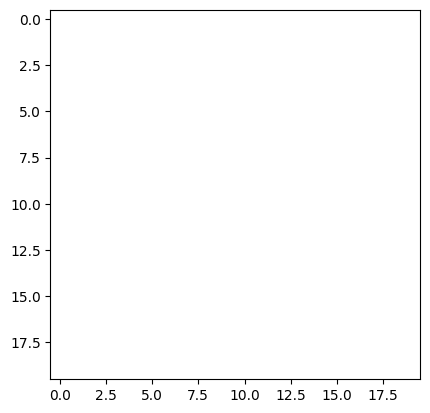

In [9]:
from matplotlib import pyplot as plt
plt.imshow(prediction_stack[0].permute(1,2,0))